# Semantic Search and Summarization Engine for ML Research Papers

Pipeline: **Data loading → EDA → Preprocessing → Sentence Embeddings → FAISS Semantic Search → Abstractive Summarization → Keyword Extraction → Clustering → Named Entity Recognition → Metadata Cards**

Dataset: [`CShorten/ML-ArXiv-Papers`](https://huggingface.co/datasets/CShorten/ML-ArXiv-Papers) — titles and abstracts of ML papers from arXiv.

##Setup

Mounting Google Drive
Used to cache heavy computations (embeddings, FAISS index, entity counts) so they don't need to be regenerated every session as it is done on colab.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
SAVE_DIR = "/content/drive/MyDrive/arxiv_search_project"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Save directory ready:", SAVE_DIR)

Save directory ready: /content/drive/MyDrive/arxiv_search_project


##Install Dependencies and Importing libraries

In [3]:
!pip install datasets sentence-transformers faiss-cpu "transformers<5" keybert scikit-learn spacy -q
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 94.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 34.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 55.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the pac

In [4]:
import pickle
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import spacy
import faiss
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from transformers import pipeline
from keybert import KeyBERT
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

##Exploratory Data Analysis (EDA)


In [5]:
raw_dataset = load_dataset("CShorten/ML-ArXiv-Papers",split="train")
eda_df = pd.DataFrame(raw_dataset)
eda_df.shape

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/986 [00:00<?, ?B/s]

ML-Arxiv-Papers.csv:   0%|          | 0.00/147M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/117592 [00:00<?, ? examples/s]

(117592, 4)

In [6]:
eda_df.columns

Index(['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'], dtype='object')

In [7]:
eda_df.isnull().sum()

,0
Unnamed: 0.1,0
Unnamed: 0,5000
title,0
abstract,0


In [8]:
eda_df.head(3)

,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...


In [9]:
abstract_word_counts = eda_df["abstract"].str.split().str.len()
title_word_counts = eda_df["title"].str.split().str.len()
print("Abstract length (words):")
print(abstract_word_counts.describe())
print()
print("Title length (words):")
print(title_word_counts.describe())

Abstract length (words):
count    117592.000000
mean        166.952947
std          49.939714
min           1.000000
25%         132.000000
50%         164.000000
75%         200.000000
max         498.000000
Name: abstract, dtype: float64

Title length (words):
count    117592.000000
mean          9.013725
std           3.188771
min           1.000000
25%           7.000000
50%           9.000000
75%          11.000000
max          33.000000
Name: title, dtype: float64


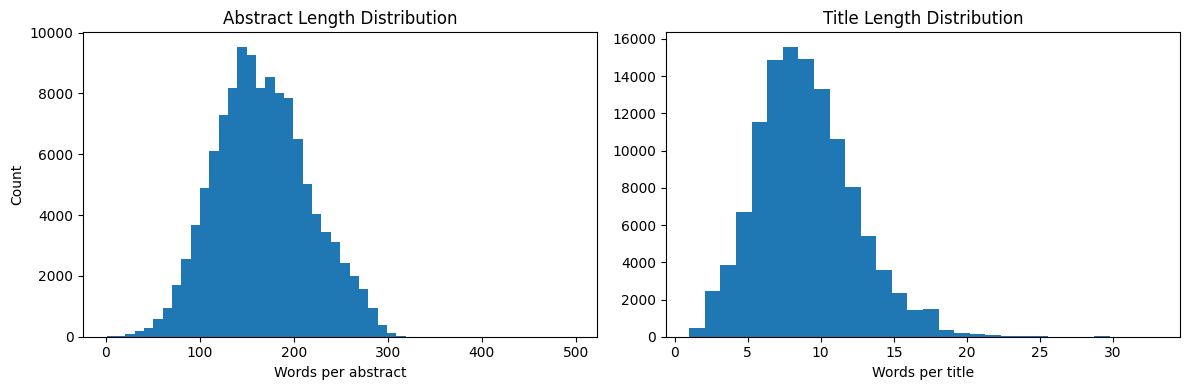

In [10]:
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].hist(abstract_word_counts,bins=50)
axes[0].set_title("Abstract Length Distribution")
axes[0].set_xlabel("Words per abstract")
axes[0].set_ylabel("Count")
axes[1].hist(title_word_counts,bins=30)
axes[1].set_title("Title Length Distribution")
axes[1].set_xlabel("Words per title")
plt.tight_layout()
plt.show()

##Preprocessing , generating Embeddings and FAISS Index
If we ran once and saved embeddings on drive then it will pick embeddings directly from there else it will generate embeddings.


In [11]:
faiss_path = f"{SAVE_DIR}/faiss_index.bin"
df_path = f"{SAVE_DIR}/df.pkl"
embeddings_path = f"{SAVE_DIR}/embeddings.pkl"
model = SentenceTransformer("all-MiniLM-L6-v2")

if os.path.exists(faiss_path) and os.path.exists(df_path) and os.path.exists(embeddings_path):
    index = faiss.read_index(faiss_path)
    df = pd.read_pickle(df_path)
    with open(embeddings_path, "rb") as f:
        embedding = pickle.load(f)
    print(f"Loaded from Drive: {len(df)} papers,{index.ntotal} vectors")
else:
    df = eda_df[["title", "abstract"]].head(15000).copy()
    df["paper_text"] = df["title"]+" "+df["abstract"]
    df["paper_text"] = df["paper_text"].str.replace("\n"," ",regex=False).str.strip()
    embedding = model.encode(df["paper_text"].to_list(),batch_size=32,show_progress_bar=True)
    faiss.normalize_L2(embedding)
    index = faiss.IndexFlatIP(384)
    index.add(embedding)
    faiss.write_index(index, faiss_path)
    df.to_pickle(df_path)
    with open(embeddings_path, "wb") as f:
        pickle.dump(embedding, f)
    print(f"Generated and saved: {len(df)} papers, {index.ntotal} vectors")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Loaded from Drive: 15000 papers,15000 vectors


##Semantic Search
Embeding a query and retrieving the top-k most semantically similar papers.

In [12]:
def search_paper(query, k=5):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D,I = index.search(query_embedding, k)
    for score, idx in zip(D[0],I[0]):
        print("Similarity Score:", score)
        print("Title:",df.iloc[idx]["title"])
        print("Abstract:",df.iloc[idx]["abstract"][:500])
        print()
    return D,I

In [13]:
query = "deep learning for medical image analysis"
D,I = search_paper(query)

Similarity Score: 0.6807244
Title: A Perspective on Deep Imaging
Abstract:   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
reconstruction theories and techniques. This direction might lead to
intelligent utilization of domain knowledge from big data, innovative
approaches for image reconstruction, and superior performance

Similarity Score: 0.67092204
Title: Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?
Abstract:   Training a deep convolutional neural network (CNN) from scratch is difficult
because it requires a large amount of labeled training data and a great deal of
expertise to ensure proper convergence. A promising alternative is to fine-tune
a CNN that has been pre-trained using, for insta

##Abstractive Summarization
Uses **distilbart-cnn-12-6** to generate a short AI summary of each retrieved paper's abstract.

In [14]:
summarizer = pipeline("summarization",model="sshleifer/distilbart-cnn-12-6",device=-1)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [15]:
def search_and_summarize(query, k=5):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, k)

    for score, idx in zip(D[0],I[0]):
        print("Similarity score:",score)
        print("Title:",df.iloc[idx]["title"])
        print("Abstract:",df.iloc[idx]["abstract"][:500])
        print()
        summary = summarizer(df.iloc[idx]["abstract"],max_length=120, min_length=40,do_sample=False)
        print("AI SUMMARY:",summary[0]["summary_text"])
        print("-" *80)

In [16]:
search_and_summarize("Deep learning in medical science",k=5)

Similarity score: 0.6063826
Title: Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?
Abstract:   Training a deep convolutional neural network (CNN) from scratch is difficult
because it requires a large amount of labeled training data and a great deal of
expertise to ensure proper convergence. A promising alternative is to fine-tune
a CNN that has been pre-trained using, for instance, a large set of labeled
natural images. However, the substantial differences between natural and
medical images may advise against such knowledge transfer. In this paper, we
seek to answer the following centra

AI SUMMARY:  Training a deep convolutional neural network from scratch is difficult because it requires a large amount of labeled training data and a great deal of expertise to ensure proper convergence . A promising alternative is to fine-tune a CNN that has been pre-trained using, for instance, a large set of labeled images .
---------------------------------

##Keyword Extraction
Uses KeyBERT to extract representative keyphrases from a paper's abstract.

In [17]:
kw_model = KeyBERT(model=model)
text = df.iloc[I[0][0]]["abstract"]
keywords = kw_model.extract_keywords(text,keyphrase_ngram_range=(1, 3),stop_words=None)
keywords

[('imaging and deep', 0.5798),
 ('medical imaging to', 0.5289),
 ('image reconstruction the', 0.5288),
 ('medical imaging', 0.5281),
 ('tomographic imaging', 0.525)]

##Paper Clustering
Grouping all papers into topic clusters using the embeddings already computed then labelling each cluster with its top Term Frequency and Inverse Term Frequencies.

In [18]:
N_CLUSTERS = 15
kmeans = KMeans(n_clusters=N_CLUSTERS,random_state=42,n_init=10)
df["cluster"] = kmeans.fit_predict(embedding)
df["cluster"].value_counts().sort_index()

,count
cluster,
0,1319
1,764
2,1080
3,692
4,1341
5,730
6,730
7,865
8,1211


In [19]:
def get_cluster_top_terms(cluster_id, top_n=8):
    cluster_texts = df.loc[df["cluster"] == cluster_id, "paper_text"]
    vectorizer = TfidfVectorizer(stop_words="english", max_features=2000)
    tfidf = vectorizer.fit_transform(cluster_texts)
    scores = tfidf.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    top_idx = scores.argsort()[::-1][:top_n]
    return [terms[i] for i in top_idx]

cluster_summary = {c: get_cluster_top_terms(c) for c in sorted(df["cluster"].unique())}
for c, terms in cluster_summary.items():
    print(f"Cluster {c} ({(df['cluster']==c).sum()} papers): {', '.join(terms)}")

Cluster 0 (1319 papers): models, model, data, learning, bayesian, inference, algorithm, latent
Cluster 1 (764 papers): neural, model, recurrent, networks, speech, learning, sequence, models
Cluster 2 (1080 papers): matrix, sparse, rank, algorithm, data, problem, low, learning
Cluster 3 (692 papers): data, learning, user, model, based, users, ranking, recommendation
Cluster 4 (1341 papers): deep, networks, learning, neural, network, training, data, model
Cluster 5 (730 papers): clustering, data, algorithm, means, clusters, based, algorithms, method
Cluster 6 (730 papers): regret, algorithm, learning, problem, bandit, online, algorithms, optimal
Cluster 7 (865 papers): model, learning, models, word, topic, neural, data, text
Cluster 8 (1211 papers): data, classification, learning, feature, based, algorithm, time, features
Cluster 9 (1185 papers): learning, deep, image, model, data, networks, adversarial, network
Cluster 10 (857 papers): stochastic, optimization, gradient, convex, learnin

In [20]:
def search_with_cluster(query, k=5):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, k)

    for score, idx in zip(D[0], I[0]):
        c = df.iloc[idx]["cluster"]
        print("Similarity score:", score)
        print("Title:", df.iloc[idx]["title"])
        print(f"Cluster {c}: {', '.join(cluster_summary[c])}")
        print()

search_with_cluster("deep learning in medical science", k=5)

Similarity score: 0.60638267
Title: Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?
Cluster 9: learning, deep, image, model, data, networks, adversarial, network

Similarity score: 0.6059521
Title: Classification of MRI data using Deep Learning and Gaussian
  Process-based Model Selection
Cluster 4: deep, networks, learning, neural, network, training, data, model

Similarity score: 0.60209996
Title: A Perspective on Deep Imaging
Cluster 4: deep, networks, learning, neural, network, training, data, model

Similarity score: 0.6019772
Title: Deep Learning in Bioinformatics
Cluster 4: deep, networks, learning, neural, network, training, data, model

Similarity score: 0.6017014
Title: A deep learning approach to diabetic blood glucose prediction
Cluster 4: deep, networks, learning, neural, network, training, data, model



##Named Entity Recognition (spaCy)
**en_core_web_sm** picks up standard entities like people, organizations, dates, numbers, locations.

In [21]:
nlp = spacy.load("en_core_web_sm")
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

In [22]:
sample_text = df.iloc[I[0][0]]["abstract"]
extract_entities(sample_text)

[]

###Corpus-wide Entity Counts.
Runs NER across all papers once and saves the counts to Drive.

In [23]:
general_entity_path = f"{SAVE_DIR}/general_entity_counter.pkl"
general_label_path = f"{SAVE_DIR}/general_label_counter.pkl"

if os.path.exists(general_entity_path) and os.path.exists(general_label_path):
    with open(general_entity_path, "rb") as f:
        general_entity_counter = pickle.load(f)
    with open(general_label_path, "rb") as f:
        general_label_counter = pickle.load(f)
    print("Loaded from Drive.")
else:
    general_entity_counter = Counter()
    general_label_counter = Counter()

    for doc in nlp.pipe(df["abstract"], batch_size=64, disable=["parser"]):
        for ent in doc.ents:
            general_entity_counter[(ent.text, ent.label_)] += 1
            general_label_counter[ent.label_] += 1

    with open(general_entity_path, "wb") as f:
        pickle.dump(general_entity_counter, f)
    with open(general_label_path, "wb") as f:
        pickle.dump(general_label_counter, f)
    print("Generated and saved.")

general_label_counter.most_common()

Loaded from Drive.


[('ORG', 29263),
 ('CARDINAL', 14594),
 ('PERSON', 9261),
 ('ORDINAL', 4334),
 ('NORP', 3920),
 ('MONEY', 3101),
 ('GPE', 2899),
 ('DATE', 2636),
 ('PERCENT', 1383),
 ('PRODUCT', 953),
 ('WORK_OF_ART', 517),
 ('LOC', 337),
 ('FAC', 282),
 ('TIME', 180),
 ('QUANTITY', 143),
 ('LANGUAGE', 98),
 ('LAW', 95),
 ('EVENT', 54)]

###Top Entities per Category

In [24]:
TOP_N = 15

for label in general_label_counter:
    top_entities = [(text, count) for (text, lbl), count in general_entity_counter.items() if lbl == label]
    top_entities = sorted(top_entities, key=lambda x: x[1], reverse=True)[:TOP_N]
    print(f"\n--- Top {label} entities ---")
    for text, count in top_entities:
        print(f"{text}: {count}")


--- Top MONEY entities ---
f$: 106
$\ell_1$: 92
N$: 80
A$: 80
k$-means: 75
X$: 59
S$: 41
\alpha$: 32
C$: 30
$\ell_2$: 27
1: 23
1$: 22
n$.: 21
H$: 21
G$: 19

--- Top PERSON entities ---
Markov: 633
Gaussian: 379
RL: 211
max: 176
Lasso: 176
Monte Carlo: 175
k$: 134
Hilbert: 121
Lipschitz: 100
Fourier: 83
Gibbs: 73
Bernoulli: 68
m$: 68
Bregman: 67
Rademacher: 64

--- Top NORP entities ---
Bayesian: 1283
Gaussian: 586
Euclidean: 183
Laplacian: 116
Riemannian: 114
Hessian: 97
Boolean: 87
Gaussians: 84
Chinese: 66
non-zero: 64
Lagrangian: 45
non-Gaussian: 44
\em: 36
non-Bayesian: 27
Caffe: 26

--- Top CARDINAL entities ---
two: 4289
one: 1603
three: 1062
1: 707
2: 665
One: 481
3: 328
four: 325
zero: 306
Two: 153
five: 142
4: 125
millions: 101
10: 100
2D: 97

--- Top ORG entities ---
linear: 659
CNN: 590
RNN: 383
PCA: 347
SGD: 327
EM: 286
ML: 278
Bayes: 271
SVM: 263
GP: 197
ImageNet: 179
NP: 167
GAN: 166
MAP: 163
GPU: 161

--- Top GPE entities ---
Bayesian: 282
Newton: 131
Gibbs: 88
node: 86

##Named Entity Recognition for Biomedical terms.
Generic spaCy misses domain terms like **glucose** since they aren't classic named-entity types. **d4data/biomedical-ner-all** picks up disease or drug ortreatment-specific terms instead.

In [25]:
biomed_ner = pipeline(
    "ner", model="d4data/biomedical-ner-all", aggregation_strategy="simple", device=-1
)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/266M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/373 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cpu


###Corpus-wide Biomedical Entity Counts


In [26]:
biomed_entity_path = f"{SAVE_DIR}/biomed_entity_counter.pkl"
biomed_label_path = f"{SAVE_DIR}/biomed_label_counter.pkl"
progress_path = f"{SAVE_DIR}/biomed_progress.pkl"
abstracts_list = df["abstract"].to_list()

if os.path.exists(biomed_entity_path) and os.path.exists(progress_path):
    with open(biomed_entity_path, "rb") as f:
        biomed_entity_counter = pickle.load(f)
    with open(biomed_label_path, "rb") as f:
        biomed_label_counter = pickle.load(f)
    with open(progress_path, "rb") as f:
        start_idx = pickle.load(f)
    print(f"Resuming biomedical NER from abstract {start_idx}/{len(abstracts_list)}")
else:
    biomed_entity_counter = Counter()
    biomed_label_counter = Counter()
    start_idx = 0
    print("Starting biomedical NER from scratch")

CHECKPOINT_EVERY = 500
BATCH_SIZE = 32

for i in range(start_idx, len(abstracts_list), BATCH_SIZE):
    batch = abstracts_list[i:i + BATCH_SIZE]
    results_batch = biomed_ner(batch)
    for results in results_batch:
        for ent in results:
            biomed_entity_counter[(ent["word"], ent["entity_group"])] += 1
            biomed_label_counter[ent["entity_group"]] += 1

    if i % CHECKPOINT_EVERY == 0:
        with open(biomed_entity_path, "wb") as f:
            pickle.dump(biomed_entity_counter, f)
        with open(biomed_label_path, "wb") as f:
            pickle.dump(biomed_label_counter, f)
        with open(progress_path, "wb") as f:
            pickle.dump(i, f)
        print(f"Checkpoint saved at {i}/{len(abstracts_list)}")

with open(biomed_entity_path, "wb") as f:
    pickle.dump(biomed_entity_counter, f)
with open(biomed_label_path, "wb") as f:
    pickle.dump(biomed_label_counter, f)
with open(progress_path, "wb") as f:
    pickle.dump(len(abstracts_list), f)

print("Biomedical NER completed.")
biomed_label_counter.most_common()

Resuming biomedical NER from abstract 15000/15000
Biomedical NER completed.


[('Detailed_description', 70287),
 ('Diagnostic_procedure', 35762),
 ('Coreference', 16330),
 ('Lab_value', 8616),
 ('Sign_symptom', 7420),
 ('Disease_disorder', 5392),
 ('Biological_structure', 544),
 ('Therapeutic_procedure', 420),
 ('Duration', 179),
 ('Activity', 176),
 ('Other_entity', 157),
 ('Severity', 156),
 ('Medication', 114),
 ('Subject', 111),
 ('Other_event', 109),
 ('Nonbiological_location', 98),
 ('Clinical_event', 90),
 ('Quantitative_concept', 87),
 ('Family_history', 82),
 ('History', 64),
 ('Date', 49),
 ('Frequency', 33),
 ('Occupation', 19),
 ('Outcome', 18),
 ('Qualitative_concept', 15),
 ('Time', 13),
 ('Texture', 12),
 ('Shape', 11),
 ('Color', 9),
 ('Dosage', 9),
 ('Sex', 6),
 ('Personal_background', 6),
 ('Distance', 4),
 ('Age', 4),
 ('Volume', 3),
 ('Administration', 3),
 ('Biological_attribute', 1)]

##Combined Entity Extraction
Merges general (spaCy) and biomedical entities for a single paper — general entities cover dates/orgs/people, biomedical covers disease/drug/technical terms.

In [27]:
def extract_entities_combined(text):
    entities = [(ent.text, ent.label_, "general") for ent in nlp(text).ents]
    entities += [(ent["word"], ent["entity_group"],"biomedical") for ent in biomed_ner(text)]
    return entities

In [28]:
sample_text = df.iloc[I[0][0]]["abstract"]
combined_entities = extract_entities_combined(sample_text)
for text, label, source in combined_entities:
    print(f"{text:30s} | {label:15s} | ({source})")

In [29]:
def search_with_entities(query, k=5):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, k)

    for score, idx in zip(D[0], I[0]):
        print("Similarity score:", score)
        print("Title:", df.iloc[idx]["title"])
        print("Entities:", extract_entities_combined(df.iloc[idx]["abstract"]))
        print("-" * 80)
search_with_entities("deep learning in medical science", k=5)

Similarity score: 0.60638267
Title: Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?
Entities: [('CNN', 'ORG', 'general'), ('CNN', 'ORG', 'general'), ('CNN', 'ORG', 'general'), ('4', 'CARDINAL', 'general'), ('3', 'CARDINAL', 'general'), ('3', 'CARDINAL', 'general'), ('1', 'CARDINAL', 'general'), ('CNN', 'ORG', 'general'), ('CNN', 'ORG', 'general'), ('2', 'CARDINAL', 'general'), ('3', 'CARDINAL', 'general'), ('4', 'CARDINAL', 'general'), ('convolutional neural network', 'Diagnostic_procedure', 'biomedical'), ('cnn', 'Diagnostic_procedure', 'biomedical'), ('cnn', 'Diagnostic_procedure', 'biomedical'), ('large', 'Detailed_description', 'biomedical'), ('natural', 'Detailed_description', 'biomedical'), ('em', 'Detailed_description', 'biomedical'), ('pre', 'Detailed_description', 'biomedical'), ('trained', 'Detailed_description', 'biomedical'), ('deep cnn', 'Detailed_description', 'biomedical'), ('cnn', 'Diagnostic_procedure', 'biomedical'), ('distinc

##Paper Metadata Card
Combines Summary + Keywords + Combined Entities into a single readable profile for each paper.

In [30]:
def generate_paper_card(idx):
    row = df.iloc[idx]
    abstract = row["abstract"]
    summary = summarizer(abstract, max_length=120, min_length=40, do_sample=False)[0]["summary_text"]
    keywords = [kw for kw, score in kw_model.extract_keywords(abstract, keyphrase_ngram_range=(1, 3), stop_words=None)]
    entities = extract_entities_combined(abstract)

    return {"Title": row["title"], "Summary": summary, "Keywords": keywords, "Entities": entities}

In [31]:
def print_paper_card(card, width=80):
    print("\n" + "=" * width)
    print(f"TITLE: {card['Title']}")
    print("=" *width)
    print("\nSUMMARY:")
    print(f"  {card['Summary']}")
    print("\nKEYWORDS:")
    for kw in card["Keywords"]:
        print(f"  - {kw}")
    print("\nENTITIES:")
    if card["Entities"]:
        for text, label, source in card["Entities"]:
            print(f"  - {text:<30} | {label:<15} | ({source})")
    else:
        print("  - None found")
    print("=" *width + "\n")

In [32]:
bio_labels = {"Diagnostic_procedure", "Disease_disorder", "Sign_symptom",
               "Biological_structure", "Therapeutic_procedure", "Medication"}
generic_labels = {"prediction", "search", "based", "immediate", "conventional",
                 "improvement", "large", "deep", "learning", "model", "training"}

def extract_entities_combined(text, min_confidence=0.85):
    general = list(set((ent.text, ent.label_, "general") for ent in nlp(text).ents))
    biomed_raw = biomed_ner(text)
    biomed = list(set((ent["word"], ent["entity_group"], "biomedical")
        for ent in biomed_raw
        if ent["score"] >= min_confidence
        and ent["entity_group"] in bio_labels
        and ent["word"].lower().strip() not in generic_labels
        and not ent["word"].isdigit()
        and not ent["word"].startswith("##")
    ))
    return general + biomed

In [33]:
def search_with_cards(query, k=5):
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, k)

    for score, idx in zip(D[0], I[0]):
        print("Similarity score:", score)
        print_paper_card(generate_paper_card(idx))

search_with_cards("deep learning in medical science", k=5)

Similarity score: 0.60638267

TITLE: Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?

SUMMARY:
   Training a deep convolutional neural network from scratch is difficult because it requires a large amount of labeled training data and a great deal of expertise to ensure proper convergence . A promising alternative is to fine-tune a CNN that has been pre-trained using, for instance, a large set of labeled images .

KEYWORDS:
  - trained cnns fine
  - of deep cnns
  - cnn from scratch
  - training deep cnn
  - pre trained cnns

ENTITIES:
  - CNN                            | ORG             | (general)
  - 1                              | CARDINAL        | (general)
  - 3                              | CARDINAL        | (general)
  - 2                              | CARDINAL        | (general)
  - 4                              | CARDINAL        | (general)
  - cnn                            | Diagnostic_procedure | (biomedical)
  - convolutional ne